# TP3.3 : Modèle épidémiologique SIR sur réseau

## Question a) Résolution analytique de l'équation (3.14)

L'équation à résoudre est la suivante :
$$u = \frac{1}{[1 + T(\kappa - 1)(1 - u)]^2} \equiv f(u)$$

Pour simplifier les calculs, on pose la constante $A = T(\kappa - 1)$. L'équation devient :
$$u = \frac{1}{[1 + A(1 - u)]^2}$$

En multipliant par le dénominateur, on obtient :
$$u [1 + A(1 - u)]^2 = 1$$

On développe ensuite l'expression:
$$u [1 + 2A(1 - u) + A^2(1 - u)^2] = 1$$
$$u [1 + 2A - 2Au + A^2(1 - 2u + u^2)] = 1$$
$$u [1 + 2A - 2Au + A^2 - 2A^2u + A^2u^2] = 1$$

En regroupant les termes selon les puissances de $u$, on obtient:
$$A^2 u^3 - 2A(A + 1) u^2 + (A + 1)^2 u - 1 = 0$$

On remarque que si $u = 1$, l'équation (3.14) donne $1 = 1 / [1 + 0]^2 = 1$. Donc, $(u - 1)$ est un facteur du polynôme.

Par division polynomiale, on obtient :
$$(u - 1) [A^2 u^2 - (A^2 + 2A) u + 1] = 0$$

On cherche les racines de la partie droite de l'équation. Les deux autres racines sont donc :
$$u = \frac{(A^2 + 2A) \pm \sqrt{A^4 + 4A^3}}{2A^2}$$

Les trois racines sont :

1.  $$u_1 = \frac{A^2 + 2A + \sqrt{A^4 + 4A^3}}{2A^2}$$
2.  $$u_2 = \frac{A^2 + 2A - \sqrt{A^4 + 4A^3}}{2A^2}$$
3.  $$u_3 = 1$$

Le résultat des racines peut être calculé manuellement, ou numériquement avec la fonction suivante:

In [3]:
import numpy as np

def get_analytical_roots(T, kappa):
    """Calcule les 3 racines analytiques pour une valeur de T donnée."""
    if T == 0:
        return [1.0] # Cas limite
    
    A = T * (kappa - 1)
    delta = A**4 + 4*A**3
    
    u1 = (A**2 + 2*A + np.sqrt(delta)) / (2 * A**2)
    u2 = (A**2 + 2*A - np.sqrt(delta)) / (2 * A**2)
    u3 = 1.0
    
    return sorted([u1, u2, u3])

print(f"Racines analytiques pour T=0.3 : {get_analytical_roots(0.3, 5)}")

Racines analytiques pour T=0.3 : [0.29250033360026706, 1.0, 2.3741663330663996]


## Question b) Sélection de la solution physique

La variable $u$ représente une probabilité, elle doit donc obligatoirement satisfaire la condition $0 \le u \le 1$. Parmi les solutions obtenues à la question précédente, la valeur $u \approx 2.374$ est rejetée car elle est supérieure à 1, ce qui est physiquement impossible. La solution $u = 1$ correspond au cas trivial où aucune transmission n’a lieu au sein de la population, ce qui implique une taille d'épidémie $R_\infty = 0$. Puisque l'énoncé précise que $u$ est la plus petite solution non négative de l'équation (3.14), la solution physiquement pertinente pour décrire la propagation de la maladie est la racine $u \approx 0.2925$ (pour $T=0.3$).

## Question c) Analyse de la taille finale de l'épidémie $R_\infty$

Pour obtenir les différentes valeurs de $u$ plutôt que de tout calculer analytiquement, nous utilisons la méthode numérique de relaxation qui permet d'évaluer précisément cette variable de probabilité pour chaque valeur de $T$. Cette approche par itération de point fixe est essentielle pour résoudre l'équation (3.14) rapidement pour l'utiliser dans l'expression de $R_\infty$. Le script présenté ci-dessous détaille l'implémentation de cet algorithme ainsi que la boucle de calcul nécessaire pour balayer l'intervalle complet de transmissibilité et identifier dynamiquement le seuil épidémique.

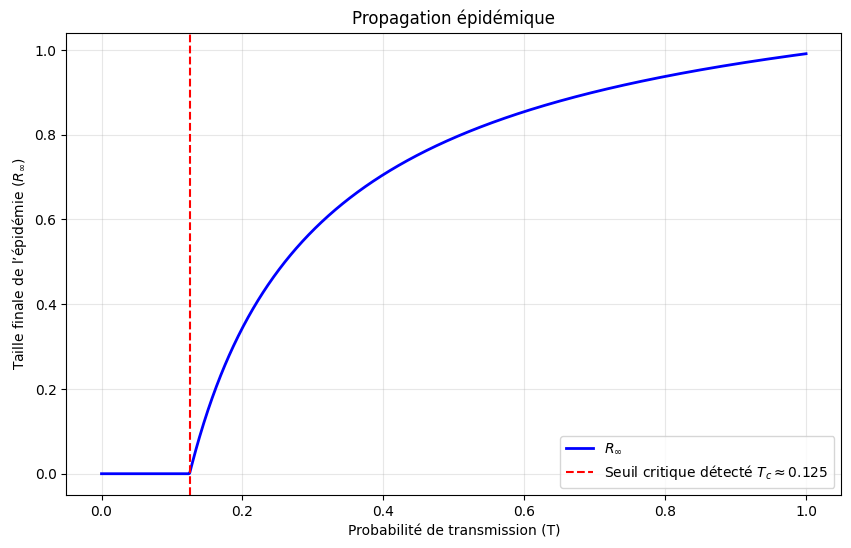

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
kappa = 5
tol = 1e-10
Max_iter = 1000

def f(u, T, kappa):
    return 1 / (1 + T*(kappa-1)*(1-u))**2

def R_inf(u, T, kappa):
    return 1 - (1 - T*(1-u))/(1 + T*(kappa-1)*(1-u))

def relaxation_method(T, kappa, tol, max_iter):
    u = 0.5  # Valeur initiale
    for i in range(max_iter):
        u_new = f(u, T, kappa)
        if abs(u_new - u) < tol:
            return u_new
        u = u_new
    return u

# Calcul de R_inf pour T de 0 à 1
T_values = np.linspace(0, 1, 1000)
R_inf_values = []

for t_val in T_values:
    u_c = relaxation_method(t_val, kappa, tol, Max_iter)
    Rinf = R_inf(u_c, t_val, kappa)
    R_inf_values.append(Rinf)

# Trouver la valeur de T critique où R_inf devient significatif
R_array = np.array(R_inf_values)
seuil_detection = 1e-4 
indices_positifs = np.where(R_array > seuil_detection)[0]
if len(indices_positifs) > 0:
    idx_seuil = indices_positifs[0]
    Tc_detecte = T_values[idx_seuil]
else:
    Tc_detecte = 0

# Graphique
plt.figure(figsize=(10, 6))
plt.plot(T_values, R_inf_values, color='blue', lw=2, label='$R_{\\infty}$')
plt.axvline(x=Tc_detecte, color='red', linestyle='--', label=f'Seuil critique détecté $T_c \\approx {Tc_detecte:.3f}$')

plt.xlabel('Probabilité de transmission (T)')
plt.ylabel('Taille finale de l’épidémie ($R_{\\infty}$)')
plt.title('Propagation épidémique')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

L'analyse du graphique de la taille finale de l'épidémie $R_\infty$ en fonction de la probabilité de transmission $T$ révèle un changement qualitatif majeur qui correspond à une transition de phase épidémique détectée numériquement à $T_c \approx 0.125$. Pour des valeurs de $T$ inférieures à ce seuil, la fraction de la population infectée demeure nulle car la maladie ne possède pas une transmissibilité suffisante pour se propager et finit par s'éteindre naturellement après seulement quelques contacts au sein du réseau. Dès que $T$ franchit cette valeur critique, on observe un « décollage » soudain de la courbe où $R_\infty$ croît rapidement, montrant qu'une fraction significative de la population est désormais atteinte par l'agent pathogène. Ce phénomène s'interprète physiquement comme l'atteinte d'un seuil de percolation où la condition de stabilité de la solution triviale $u=1$ est rompue lorsque $2T(\kappa-1) = 1$, ce qui donne précisément $T_c = 1 / [2(5-1)] = 0.125$. À ce point précis, le virus devient assez contagieux pour former une composante géante d'infection à travers le réseau. On peut finalement observer que $R_\infty$ croît de plus en plus lentement à mesure que $T$ augmente pour tendre vers une valeur maximale proche de 1, ce qui signifie que la quasi-totalité de la population finit par être infectée lorsque la transmission est totale. Par exemple, pour un taux de transmission maximal ($T=1$) avec une moyenne de $\kappa=5$, on calcule que $R_\infty$ atteint environ 99,1 % de la population, ce qui signifie que la quasi-totalité des individus finit par être infectée sans jamais atteindre le 100 % absolu pour des raisons statistiques.